# Modelado Supervisado - Predicción de Enfermedad Cardiovascular

En este notebook se desarrollará el proceso de modelado supervisado utilizando el dataset completo generado después del Feature Engineering.

El objetivo principal es entrenar y comparar diferentes modelos de clasificación para predecir la presencia de enfermedad cardiovascular (`cardio`). Para ello, se evaluarán varios algoritmos mediante métricas como accuracy, precision, recall, F1-score y ROC-AUC.

In [23]:
# Librerías principales
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# División de datos y escalado
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# Configuración visual
sns.set(style="whitegrid")

In [24]:
# Cargar dataset completo después del Feature Engineering
df = pd.read_csv("cardio_features_full.csv")

df.head()

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,...,bmi_category,obesity,bp_category,hypertension,metabolic_risk,lifestyle_risk,risk_score,pulse_pressure,mean_arterial_pressure,age_pressure
0,50,2,168,62.0,110,80,1,1,0,0,...,normal,0,hipertension_etapa_1,1,0,0,1,30,90.000000,5500
1,55,1,156,85.0,140,90,3,1,0,0,...,obesidad,1,hipertension_etapa_2,1,1,0,3,50,106.666667,7700
2,51,1,165,64.0,130,70,3,1,0,0,...,normal,0,hipertension_etapa_1,1,1,1,3,60,90.000000,6630
3,48,2,169,82.0,150,100,1,1,0,0,...,sobrepeso,0,hipertension_etapa_2,1,0,0,1,50,116.666667,7200
4,47,1,156,56.0,100,60,1,1,0,0,...,normal,0,normal,0,0,1,1,40,73.333333,4700


In [25]:
# Revisar dimensiones
df.shape

(65307, 23)

In [26]:
# Revisar columnas
df.columns

Index(['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi',
       'bmi_category', 'obesity', 'bp_category', 'hypertension',
       'metabolic_risk', 'lifestyle_risk', 'risk_score', 'pulse_pressure',
       'mean_arterial_pressure', 'age_pressure'],
      dtype='str')

In [27]:
# Variable objetivo
y = df["cardio"]

# Variables predictoras
X = df.drop(columns=["cardio"])

In [28]:
# Convertir variables categóricas a dummies 
X = pd.get_dummies(X, drop_first=True)

In [29]:
# Separación entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (52245, 26)
X_test: (13062, 26)
y_train: (52245,)
y_test: (13062,)


In [30]:
# Escalado de variables
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Evaluación de modelos

### Dataset completo

In [31]:
# Modelos base para comparación inicial

modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [32]:
resultados = []

for nombre, modelo in modelos.items():
    print(f"Entrenando modelo: {nombre}")
    
    modelo.fit(X_train_scaled, y_train)
    
    y_pred = modelo.predict(X_test_scaled)
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    
    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

resultados_df = pd.DataFrame(resultados)

# Mostrar resultados ordenados por ROC-AUC
resultados_df.sort_values(by="ROC-AUC", ascending=False)

Entrenando modelo: Logistic Regression
Entrenando modelo: Decision Tree
Entrenando modelo: Random Forest
Entrenando modelo: SVM


c:\Users\igorc\OneDrive\Documentos\ana_cabrera\IA 3er semestre\ADQISICION, ANALISIS Y PROCESAMIENTO DE DATOS\PROYECTO_FINAL_2\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Entrenando modelo: KNN
Entrenando modelo: Naive Bayes


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.727224,0.750820,0.691285,0.719824,0.792053
3,SVM,0.727147,0.760525,0.673916,0.714606,0.785017
5,Naive Bayes,0.708391,0.728025,0.677994,0.702119,0.768212
2,Random Forest,0.685730,0.692002,0.684791,0.688378,0.740905
4,KNN,0.684964,0.694203,0.676484,0.685229,0.733456
1,Decision Tree,0.612311,0.619567,0.609274,0.614377,0.611948


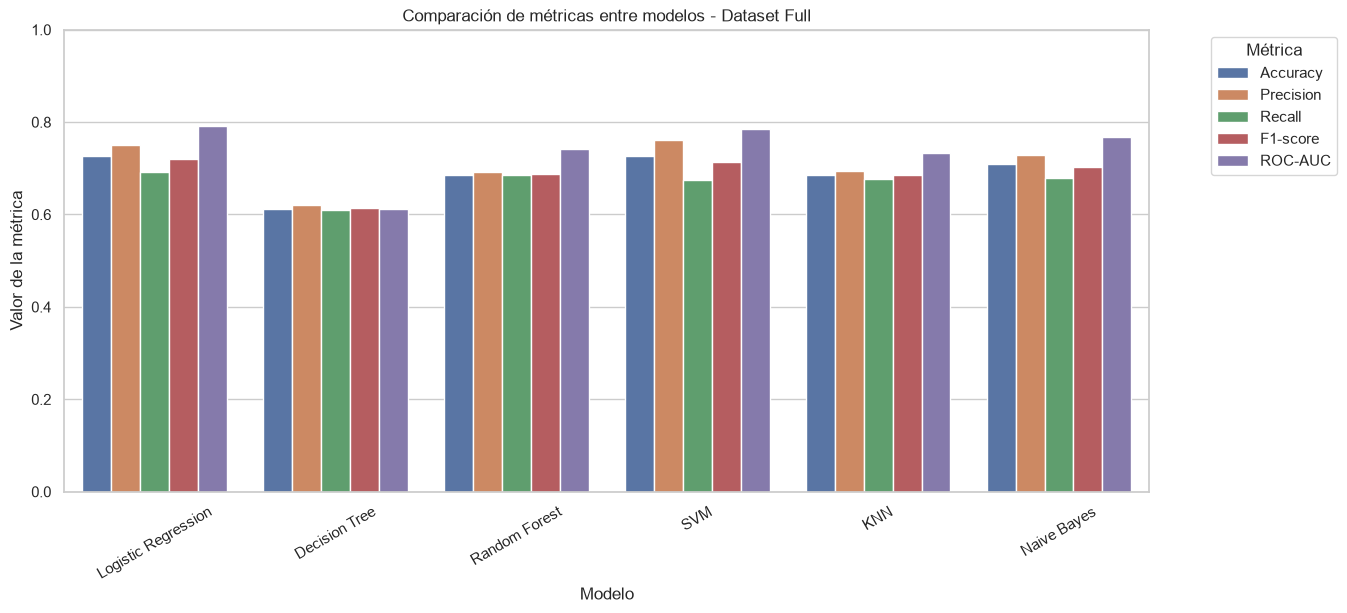

In [33]:
# Convertir resultados a formato largo para graficar
resultados_melted = resultados_df.melt(
    id_vars="Modelo",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=resultados_melted,
    x="Modelo",
    y="Valor",
    hue="Métrica"
)

plt.title("Comparación de métricas entre modelos - Dataset Full")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(title="Métrica", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

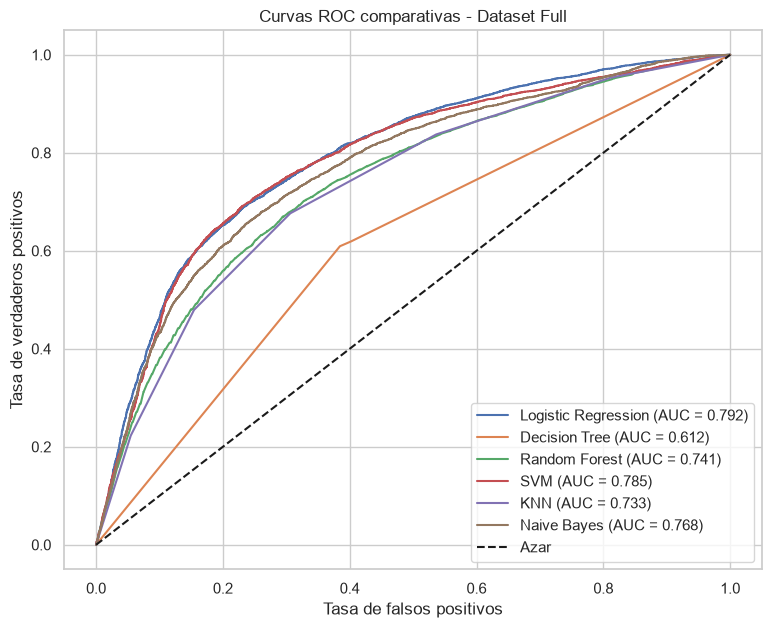

In [34]:
plt.figure(figsize=(9, 7))

for nombre, modelo in modelos.items():
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Azar")

plt.title("Curvas ROC comparativas - Dataset Full")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.grid(True)

plt.show()

In [35]:
def evaluar_dataset(df_modelo, nombre_dataset):
    print("=" * 80)
    print(f"EVALUACIÓN DE MODELOS - {nombre_dataset}")
    print("=" * 80)
    
    # Separar variable objetivo y predictoras
    y = df_modelo["cardio"]
    X = df_modelo.drop(columns=["cardio"])
    
    # Convertir variables categóricas a dummies si existen
    X = pd.get_dummies(X, drop_first=True)
    
    # División entrenamiento/prueba
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    # Escalado
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Modelos base
    modelos = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "SVM": SVC(probability=True, random_state=42),
        "KNN": KNeighborsClassifier(),
        "Naive Bayes": GaussianNB()
    }
    
    resultados = []
    
    # Entrenamiento y métricas
    for nombre, modelo in modelos.items():
        print(f"Entrenando modelo: {nombre}")
        
        modelo.fit(X_train_scaled, y_train)
        
        y_pred = modelo.predict(X_test_scaled)
        y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
        
        resultados.append({
            "Modelo": nombre,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba)
        })
    
    resultados_df = pd.DataFrame(resultados)
    resultados_df = resultados_df.sort_values(by="ROC-AUC", ascending=False)
    
    display(resultados_df)
    
    # Gráfica de barras comparativa
    resultados_melted = resultados_df.melt(
        id_vars="Modelo",
        value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
        var_name="Métrica",
        value_name="Valor"
    )
    
    plt.figure(figsize=(14, 6))
    
    sns.barplot(
        data=resultados_melted,
        x="Modelo",
        y="Valor",
        hue="Métrica"
    )
    
    plt.title(f"Comparación de métricas entre modelos - {nombre_dataset}")
    plt.xlabel("Modelo")
    plt.ylabel("Valor de la métrica")
    plt.ylim(0, 1)
    plt.xticks(rotation=30)
    plt.legend(title="Métrica", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()
    
    # Curvas ROC comparativas
    plt.figure(figsize=(9, 7))
    
    for nombre, modelo in modelos.items():
        y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
        
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)
        
        plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc_score:.3f})")
    
    plt.plot([0, 1], [0, 1], "k--", label="Azar")
    
    plt.title(f"Curvas ROC comparativas - {nombre_dataset}")
    plt.xlabel("Tasa de falsos positivos")
    plt.ylabel("Tasa de verdaderos positivos")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return resultados_df

### Dataset reducido 1

In [36]:
# cargar datasets reducidos
df_reduced_v1 = pd.read_csv("cardio_features_reduced1.csv")

EVALUACIÓN DE MODELOS - Dataset Reducido V1
Entrenando modelo: Logistic Regression
Entrenando modelo: Decision Tree
Entrenando modelo: Random Forest
Entrenando modelo: SVM


c:\Users\igorc\OneDrive\Documentos\ana_cabrera\IA 3er semestre\ADQISICION, ANALISIS Y PROCESAMIENTO DE DATOS\PROYECTO_FINAL_2\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Entrenando modelo: KNN
Entrenando modelo: Naive Bayes


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.726688,0.749632,0.691889,0.719604,0.792185
3,SVM,0.728143,0.761677,0.674823,0.715624,0.785776
5,Naive Bayes,0.707931,0.721713,0.689775,0.705383,0.767310
2,Random Forest,0.685959,0.691152,0.687812,0.689478,0.736625
4,KNN,0.685883,0.692980,0.682827,0.687866,0.732977
1,Decision Tree,0.615220,0.622073,0.613805,0.617911,0.614562


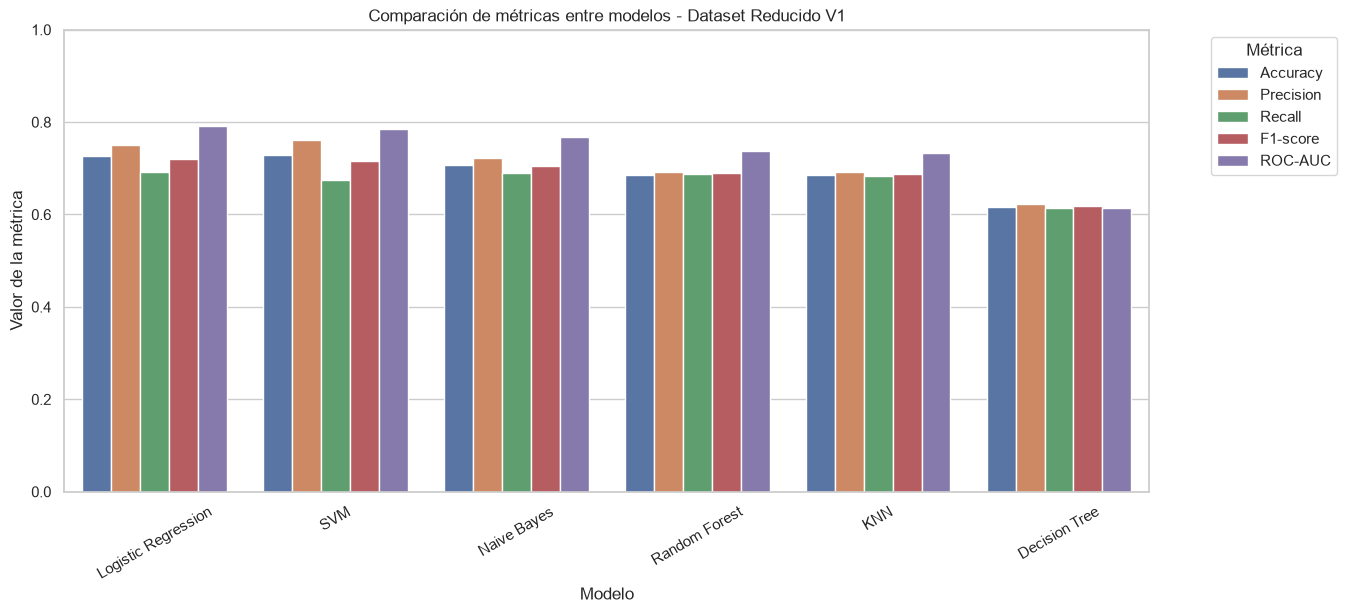

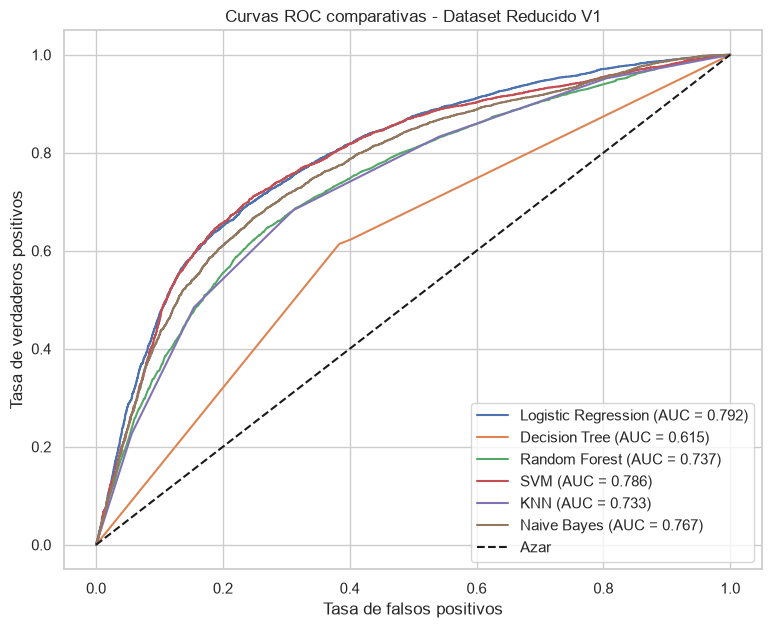

In [37]:
resultados_reduced_v1 = evaluar_dataset(
    df_reduced_v1,
    "Dataset Reducido V1"
)

### Dataset reducido 2

In [38]:
# cargar datasets reducidos
df_reduced_v2 = pd.read_csv("cardio_features_reduced2.csv")

EVALUACIÓN DE MODELOS - Dataset Reducido V2
Entrenando modelo: Logistic Regression
Entrenando modelo: Decision Tree
Entrenando modelo: Random Forest
Entrenando modelo: SVM


c:\Users\igorc\OneDrive\Documentos\ana_cabrera\IA 3er semestre\ADQISICION, ANALISIS Y PROCESAMIENTO DE DATOS\PROYECTO_FINAL_2\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Entrenando modelo: KNN
Entrenando modelo: Naive Bayes


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.724315,0.748682,0.686603,0.716300,0.790710
3,SVM,0.728219,0.763424,0.672104,0.714859,0.779886
5,Naive Bayes,0.708161,0.722196,0.689473,0.705455,0.765956
4,KNN,0.684964,0.691649,0.682978,0.687286,0.732119
2,Random Forest,0.660848,0.663045,0.672859,0.667916,0.714738
1,Decision Tree,0.621880,0.629664,0.616825,0.623178,0.622397


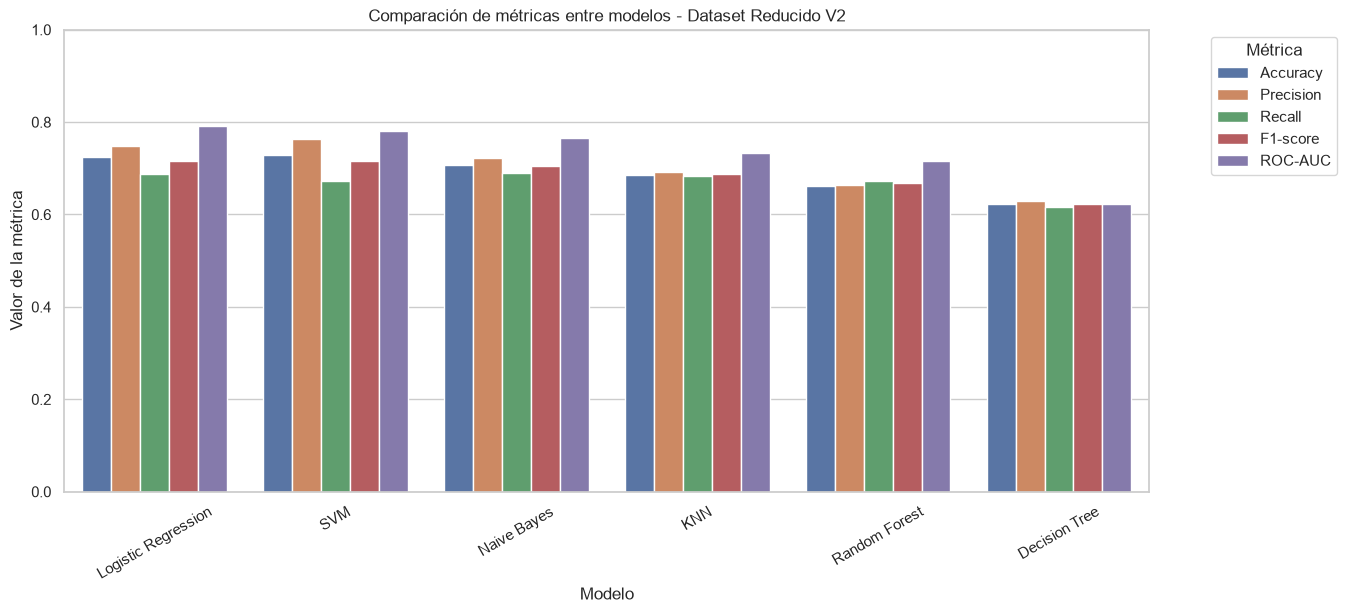

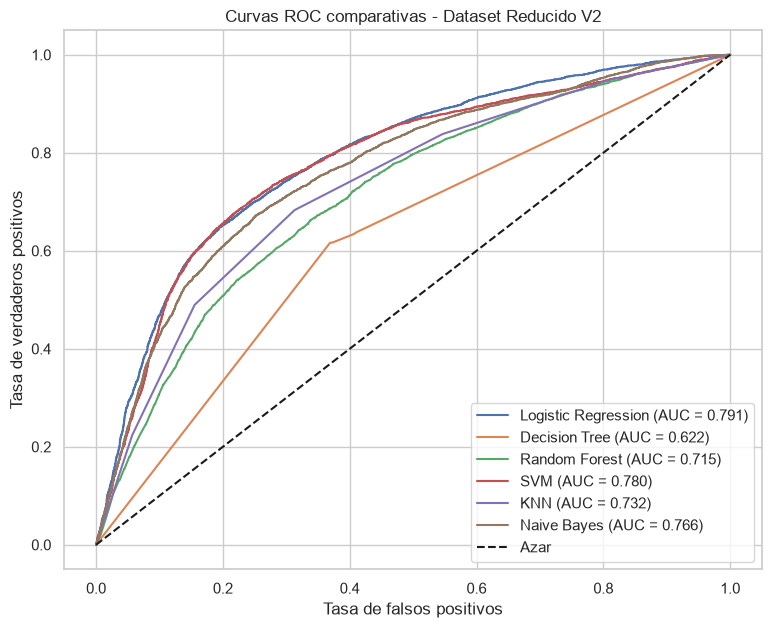

In [39]:
resultados_reduced_v2 = evaluar_dataset(
    df_reduced_v2,
    "Dataset Reducido V2"
)

### Dataset reducido 3

In [40]:
df_reduced_v3 = pd.read_csv("cardio_features_reduced3.csv")

EVALUACIÓN DE MODELOS - Dataset Reducido V3
Entrenando modelo: Logistic Regression
Entrenando modelo: Decision Tree
Entrenando modelo: Random Forest
Entrenando modelo: SVM


c:\Users\igorc\OneDrive\Documentos\ana_cabrera\IA 3er semestre\ADQISICION, ANALISIS Y PROCESAMIENTO DE DATOS\PROYECTO_FINAL_2\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Entrenando modelo: KNN
Entrenando modelo: Naive Bayes


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.723243,0.755612,0.671047,0.710823,0.789800
3,SVM,0.727683,0.759134,0.677843,0.716189,0.785801
5,Naive Bayes,0.690936,0.701560,0.679203,0.690200,0.756734
2,Random Forest,0.683816,0.689085,0.685546,0.687311,0.739509
4,KNN,0.683356,0.692189,0.675880,0.683937,0.731228
1,Decision Tree,0.606492,0.612214,0.610180,0.611195,0.605965


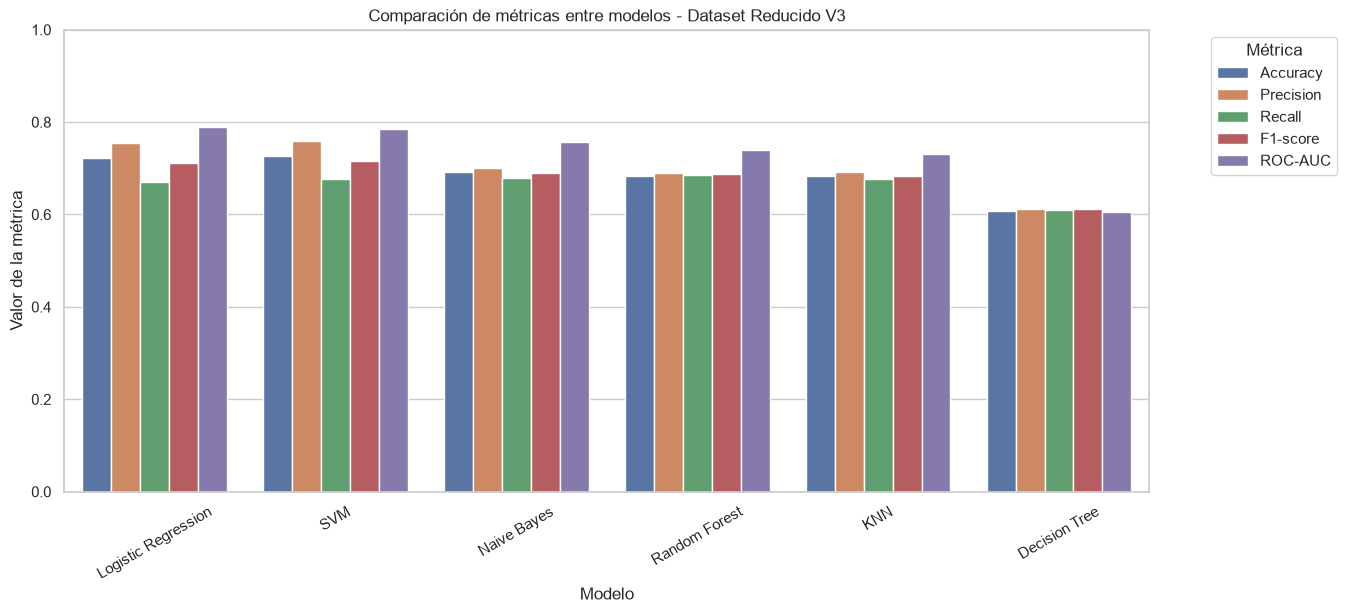

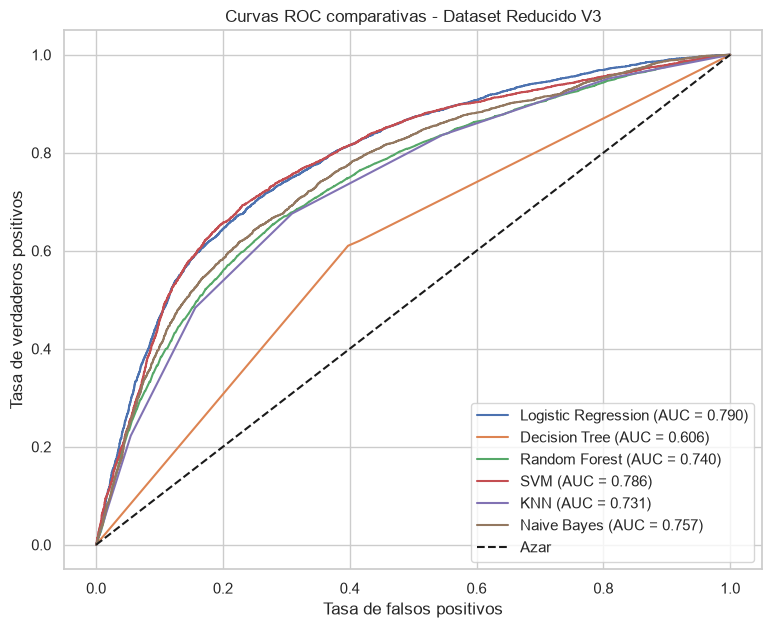

In [41]:
# evaluar dataset reducido 3
resultados_reduced_v3 = evaluar_dataset(
    df_reduced_v3,
    "Dataset Reducido V3"
)

## Comparacion y optimizacion de modelos
modelos seleccionados:
- VFULL - Regresion logistica
- V3 - SVM
- V3 - Random forest     
Después de comparar los modelos base en las distintas versiones del dataset, se decidió optimizar tres combinaciones específicas: Logistic Regression con el dataset Full, SVM con el dataset Reducido V3 y Random Forest con el dataset Reducido V3. Esta decisión se tomó porque Logistic Regression obtuvo su mejor desempeño general en el dataset Full, especialmente en ROC-AUC y F1-score; SVM presentó una ligera mejora en todas sus métricas al utilizar la versión V3; y Random Forest alcanzó su mejor recall en V3, métrica relevante en un problema de salud, ya que permite identificar una mayor proporción de casos positivos. Por esta razón, la optimización no se realizará sobre un único dataset, sino sobre la mejor combinación modelo-dataset observada en la comparación inicial.
